# 미래 수요 예측 (2024년 4월 ~ 2025년 12월)
이 노트북은 다음 단계를 수행합니다:
1. **풍부한 데이터 로드**: `df_hs.csv` (인구, 경제, 뉴스 심리지수 등 포함) 사용
2. **미래 독립변수 예측 (Recursive)**: RandomForest를 사용하여 미래(2024.04~2025.12)의 모든 독립변수(약 90개)를 순환적으로 예측
3. **데이터 저장**: 채워진 데이터를 `df_hs_filled.csv`로 저장
4. **모델 검증 (Validation)**: 최근 1년 데이터를 사용해 CatBoost 모델 성능 검증 (Data Leakage 방지 적용)
5. **최종 예측**: 미래 기간에 대한 승차인원수 예측 및 시각화


In [17]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm

# 한글 폰트 설정 (OS에 맞게 설정 필요, 여기선 NanumGothic 예시)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)

# 경로 설정
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == 'code':
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

RAW_DATA_PATH = PROJECT_DIR / 'raw_data'
PROCESSED_DATA_PATH = PROJECT_DIR / 'processed_data'
RESULT_PATH = PROJECT_DIR / 'result'
RESULT_PATH.mkdir(exist_ok=True)

print(f"✅ 경로 설정 완료:\n   Processed: {PROCESSED_DATA_PATH}")


✅ 경로 설정 완료:
   Processed: /mnt/c/Users/Admin/PycharmProjects/Demand-Forecasting-Dive/processed_data


In [18]:
# 1. 데이터 로드 (풍부한 Feature가 포함된 df_hs.csv)
df_merged = pd.read_csv(PROCESSED_DATA_PATH / 'df_hs.csv')
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged = df_merged.sort_values('Date').reset_index(drop=True)

print(f"✅ 데이터 로드 완료: {df_merged.shape}")
print(f"   기간: {df_merged['Date'].min()} ~ {df_merged['Date'].max()}")
print(f"   컬럼 수: {len(df_merged.columns)}")


✅ 데이터 로드 완료: (132, 116)
   기간: 2015-01-01 00:00:00 ~ 2025-12-01 00:00:00
   컬럼 수: 116


In [19]:
# 2. 기본 Feature Engineering 함수 정의
def add_time_features(df):
    df = df.copy()
    
    # 달력 정보
    kr_holidays = holidays.KR()
    df['is_holiday'] = df['Date'].apply(lambda x: x in kr_holidays).astype(int)
    df['weekday'] = df['Date'].dt.weekday
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    
    # 시간 인덱스 (Trend)
    df['TimeIndex'] = (df['Date'].dt.year - df['Date'].dt.year.min()) * 12 + df['Date'].dt.month
    
    # 계절성 (Cyclical)
    df['Month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)
    df['Quarter'] = df['Date'].dt.quarter
    
    return df

# 기본 시간 변수 추가
df_merged = add_time_features(df_merged)
print("✅ 기본 시간 변수 추가 완료")


✅ 기본 시간 변수 추가 완료


In [20]:
# 3. 미래 독립변수 예측 (Recursive Forecasting)
# 목표: 2024-04 ~ 2025-12 구간의 비어있는 독립변수들을 채운다.
# 방법: LinearRegression을 사용하여 매월 순환적으로 예측 (TimeIndex 추세와 Seasonality 반영)

print("\n[미래 독립변수 예측 시작]")

# 예측 대상 컬럼 (숫자형 컬럼 중 타겟과 메타데이터 제외)
exclude_cols = ['Date', '승차인원수', 'Year', 'Month', 'TimeIndex', 'is_holiday', 'weekday', 'is_weekend', 'Month_sin', 'Month_cos', 'Quarter']
target_features = [col for col in df_merged.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

# 학습 기간 (실제 데이터가 있는 구간)
train_mask = df_merged['Date'] < '2024-04-01'
test_mask = df_merged['Date'] >= '2024-04-01'

# 각 독립변수별 모델 학습
models = {}
feature_cols = ['TimeIndex', 'Month_sin', 'Month_cos', 'Quarter', 'is_weekend', 'is_holiday']

print(f"   예측 대상 변수 개수: {len(target_features)}개")

# 1) 독립변수 예측용 모델 학습 (2024-03까지의 데이터 사용)
for col in tqdm(target_features, desc="Training Feature Models"):
    # 유효한 데이터만 사용 (NaN 제외)
    valid_data = df_merged[train_mask & df_merged[col].notna()]
    
    if len(valid_data) < 12:
        continue
        
    X_feat = valid_data[feature_cols]
    y_feat = valid_data[col]
    
    model = LinearRegression()
    model.fit(X_feat, y_feat)
    models[col] = model

# 2) 순환 예측 (Walking Forward)
future_dates = df_merged.loc[test_mask, 'Date'].reset_index(drop=True)

for i, current_date in enumerate(future_dates):
    # 현재 예측할 행의 인덱스 찾기
    current_idx = df_merged[df_merged['Date'] == current_date].index[0]
    
    # Feature 준비
    current_row = df_merged.iloc[[current_idx]].copy()
    X_test = current_row[feature_cols]
    
    # 모든 독립변수에 대해 예측 수행
    for col in target_features:
        if col in models:
            pred_val = models[col].predict(X_test)[0]
            # 예측값을 데이터프레임에 업데이트
            df_merged.at[current_idx, col] = pred_val

print(f"✅ 미래 독립변수 예측 완료 (2025-12까지)")

# 결과 저장
df_merged.to_csv(PROCESSED_DATA_PATH / 'df_hs_filled.csv', index=False)
print(f"✅ 채워진 데이터 저장 완료: processed_data/df_hs_filled.csv")



[미래 독립변수 예측 시작]
   예측 대상 변수 개수: 112개


Training Feature Models: 100%|██████████| 112/112 [00:00<00:00, 563.54it/s]


✅ 미래 독립변수 예측 완료 (2025-12까지)
✅ 채워진 데이터 저장 완료: processed_data/df_hs_filled.csv


In [21]:
# 4. 시계열 파생변수 생성 (Lags, Rolling)
# 이제 모든 기간에 대해 독립변수 값이 채워졌으므로, 전체 기간에 대해 Lag/Rolling Feature를 계산합니다.

def add_lag_rolling_features(df):
    df = df.copy()
    target = '승차인원수'
    
    # Lag Features (1, 3, 6, 12개월 전)
    for lag in [1, 3, 6, 12]:
        df[f'Lag_{lag}_{target}'] = df[target].shift(lag)
    
    # Rolling Features (3, 6, 12개월 이동평균)
    for window in [3, 6, 12]:
        df[f'Rolling_{window}_mean'] = df[target].shift(1).rolling(window=window).mean()
        df[f'Rolling_{window}_std'] = df[target].shift(1).rolling(window=window).std()
        
    return df

df_featured = add_lag_rolling_features(df_merged)

# 결측치 보간 (Data Leakage 방지: 과거 데이터 기준 통계량 사용)
print("\n[결측치 보간]")
split_date_valid = '2023-04-01'
train_impute_mask = df_featured['Date'] < split_date_valid # Validation 전까지만 사용하여 통계 산출 (2023-03까지)

# 숫자형 컬럼 보간
numeric_cols = df_featured.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_featured[col].isnull().sum() > 0:
        # 1. 선형 보간 (시계열 연속성 반영)
        df_featured[col] = df_featured[col].interpolate(method='linear', limit_direction='both')
        
        # 2. 여전히 남은 결측치는 과거 데이터 중앙값으로 채움
        if df_featured[col].isnull().sum() > 0:
            median_val = df_featured.loc[train_impute_mask, col].median()
            df_featured[col] = df_featured[col].fillna(median_val)

print(f"✅ Feature Engineering 및 결측치 처리 완료: {df_featured.shape}")



[결측치 보간]
✅ Feature Engineering 및 결측치 처리 완료: (132, 133)


Train Shape: (99, 126), Valid Shape: (12, 126)

[Validation Result]
RMSE: 162,933.32
MAE : 127,682.53


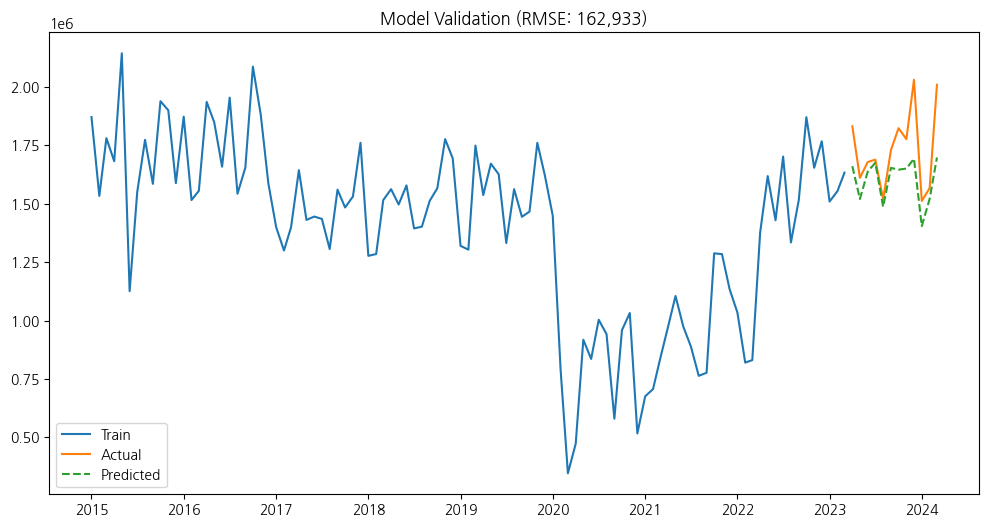

In [22]:
# 5. 모델 검증 (Validation)
# Train: ~2023.03 / Valid: 2023.04 ~ 2024.03 (~12개월)

validation_start = '2023-04-01'
validation_end = '2024-03-01'

train_data = df_featured[df_featured['Date'] < validation_start]
valid_data = df_featured[(df_featured['Date'] >= validation_start) & (df_featured['Date'] <= validation_end)]

# Feature Selection
exclude = ['Date', '승차인원수', 'Year', 'Month', 'Quarter'] # 식별자 및 타겟 제외
features = [c for c in df_featured.columns if c not in exclude and df_featured[c].dtype in [np.float64, np.int64]]
target = '승차인원수'

X_train = train_data[features]
y_train = train_data[target]
X_valid = valid_data[features]
y_valid = valid_data[target]

print(f"Train Shape: {X_train.shape}, Valid Shape: {X_valid.shape}")

# CatBoost 학습
model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, random_state=42, verbose=0)
model.fit(X_train, y_train)

# 예측 및 평가
valid_preds = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
mae = mean_absolute_error(y_valid, valid_preds)

print(f"\n[Validation Result]")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], y_train, label='Train')
plt.plot(valid_data['Date'], y_valid, label='Actual')
plt.plot(valid_data['Date'], valid_preds, label='Predicted', linestyle='--')
plt.title(f'Model Validation (RMSE: {rmse:,.0f})')
plt.legend()
plt.show()


In [23]:
# 6. 최종 미래 예측 (2024-04 ~ 2025-12)
# 전체 과거 데이터(Validation 포함)로 재학습 후 미래 예측

# 전체 학습 데이터
train_full = df_featured[df_featured['Date'] < '2024-04-01']
X_full = train_full[features]
y_full = train_full[target]

# 테스트 데이터 (이미 독립변수는 채워져 있음)
test_data = df_featured[df_featured['Date'] >= '2024-04-01'].copy()

# 모델 재학습 (RandomForest)
final_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X_full, y_full)

# Recursive Forecast for Target (승차인원수)
print("[최종 미래 예측 시작]")

# 예측 결과를 저장할 리스트
future_predictions = []

# 테스트 구간 순회
current_df = df_featured.copy()

for i in tqdm(range(len(test_data)), desc="Recursive Forecasting"):
    current_idx = test_data.index[i]
    
    # Lag/Rolling Feature 재계산
    temp_df = add_lag_rolling_features(current_df)
    
    # 현재 feature 추출
    row_features = temp_df.loc[current_idx, features].values.reshape(1, -1)
    
    # 예측
    pred = final_model.predict(row_features)[0]
    
    # 결과 저장 및 데이터프레임 업데이트
    future_predictions.append(pred)
    current_df.at[current_idx, target] = pred

print("✅ 예측 완료")


[최종 미래 예측 시작]


Recursive Forecasting: 100%|██████████| 21/21 [00:00<00:00, 38.89it/s]

✅ 예측 완료



[2024-04 ~ 2025-12 승차인원수 예측 결과]


,Date,Predicted_Demand
0,2024-04-01,1319013
1,2024-05-01,1320934
2,2024-06-01,1313547
3,2024-07-01,1323108
4,2024-08-01,1319558
5,2024-09-01,1324217
6,2024-10-01,1363557
7,2024-11-01,1370322
8,2024-12-01,1386206
9,2025-01-01,1066578


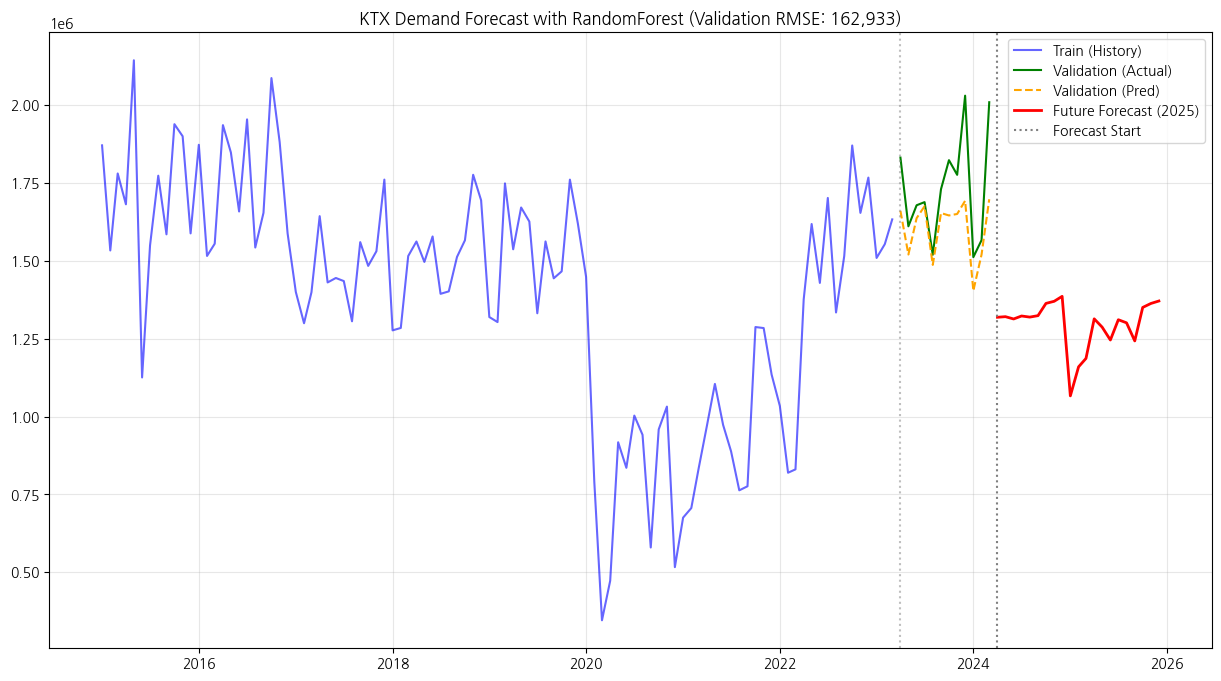

In [24]:
# 7. 결과 확인 및 저장

# 결과 데이터프레임 생성
result_df = pd.DataFrame({
    'Date': test_data['Date'].values,
    'Predicted_Demand': future_predictions
})

# 정수로 변환
result_df['Predicted_Demand'] = result_df['Predicted_Demand'].round().astype(int)

# 출력
print("\n[2024-04 ~ 2025-12 승차인원수 예측 결과]")
display(result_df)

# CSV 저장
result_df.to_csv(RESULT_PATH / 'final_forecast_2025.csv', index=False)

# 시각화 (Train, Valid, Forecast 모두 포함)
plt.figure(figsize=(15, 8))

# 1. Historical Train (~2023.03)
plt.plot(train_data['Date'], y_train, label='Train (History)', color='blue', alpha=0.6)

# 2. Validation (2023.04 ~ 2024.03)
plt.plot(valid_data['Date'], y_valid, label='Validation (Actual)', color='green')
plt.plot(valid_data['Date'], valid_preds, label='Validation (Pred)', color='orange', linestyle='--')

# 3. Future Forecast (2024.04 ~ 2025.12)
plt.plot(result_df['Date'], result_df['Predicted_Demand'], label='Future Forecast (2025)', color='red', linewidth=2)

plt.axvline(x=pd.to_datetime('2023-04-01'), color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=pd.to_datetime('2024-04-01'), color='gray', linestyle=':', label='Forecast Start')

plt.title(f'KTX Demand Forecast with RandomForest (Validation RMSE: {rmse:,.0f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
